# 🚕 Ride Demand Forecasting: Data Preprocessing Engine

---

### 📌 Project Goal
The goal of this project is to clean, transform, and merge raw ride-hailing data (`CSV`, `JSON`, and `SQL`) into a clean, model-ready dataset (`final_prepared_rides_dataset.csv`) for predicting ride demand and surge pricing.

---

### 🛠️ Key Steps Followed
* 📥 **Data Loading:** Read `riders.csv`, `trips.json`, and `city_zones.sql` datasets and inspect missing values and duplicates.
* 🧹 **Data Cleaning:** Handle missing values (`SimpleImputer` & `KNNImputer`) and remove invalid entries like negative fares.
* 📊 **Outlier Handling:** Detect extreme values using **Z-Score** and **IQR**, and fix surge fare anomalies using **Winsorization**.
* ⚙️ **Data Transformation:** Extract time features (`hour`, `day`, `month`), encode categorical attributes, and apply log/square-root transformations on skewed data.
* 📐 **Feature Scaling:** Normalize and standardize numerical attributes using `StandardScaler` and `MinMaxScaler`.
* 🏗️ **Feature Engineering:** Create custom features like `avg_ride_distance`, `is_peak_hour`, `days_since_signup`, and `surge_flag`.
* 💾 **Export & Audit:** Print a before-vs-after data summary table and export `final_prepared_rides_dataset.csv`.
* 📈 **EDA Report:** Generate an automated data profiling report (`ydata_profiling`) and key visualizations.

---

### 🧰 Tools & Technologies
* **Language:** Python
* **Data Processing:** `pandas`, `numpy`, `sqlite3`, `json`
* **Machine Learning & Stats:** `scikit-learn`, `scipy`
* **Visualization:** `matplotlib`, `seaborn`, `ydata-profiling`

#### 📦 Step 1 : Import Required Libraries

In [42]:
# System & data handling
import numpy as np
import pandas as pd
import json
import sqlite3
import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Preprocessing
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import (LabelEncoder,MinMaxScaler,OneHotEncoder,OrdinalEncoder,StandardScaler)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [43]:
# 1.1:  Load CSV, JSON, and SQL Files

# Relative file paths based on your folder structure
csv_path = "../Datasets/riders - riders.csv.csv"
json_path = "../Datasets/trips.json"
sql_path = "../Datasets/city_zones.sql"

# Load Datasets
riders_df = pd.read_csv(csv_path)
trips_df = pd.read_json(json_path)

# Load SQL dataset
conn = sqlite3.connect(":memory:")
with open(sql_path, "r") as f:
    conn.executescript(f.read())

city_zones_df = pd.read_sql_query("SELECT * FROM city_zones", conn)

print("✅ All 3 datasets loaded successfully!")

✅ All 3 datasets loaded successfully!


In [44]:
# 1.2: Display First 5 Rows, .info() Summary, and Missing Values

# 1. Display First 5 Rows for each dataset
print("🔹 --- RIDERS DATASET (First 5 Rows) ---")
display(riders_df.head())

print("🔹 --- TRIPS DATASET (First 5 Rows) ---")
display(trips_df.head())

print("🔹 --- CITY ZONES DATASET (First 5 Rows) ---")
display(city_zones_df.head())

🔹 --- RIDERS DATASET (First 5 Rows) ---


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


🔹 --- TRIPS DATASET (First 5 Rows) ---


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


🔹 --- CITY ZONES DATASET (First 5 Rows) ---


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business


In [45]:
# 2. Display .info() summary for each dataset
print("\n🔹 --- RIDERS DATASET (.info()) ---")
riders_df.info()

print("\n🔹 --- TRIPS DATASET (.info()) ---")
trips_df.info()

print("\n🔹 --- CITY ZONES DATASET (.info()) ---")
city_zones_df.info()


🔹 --- RIDERS DATASET (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB

🔹 --- TRIPS DATASET (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      20

In [46]:
# 3. Display Missing Value counts for each dataset
print("\n🔹 --- RIDERS DATASET (Missing Values) ---")
print(riders_df.isnull().sum())

print("\n🔹 --- TRIPS DATASET (Missing Values) ---")
print(trips_df.isnull().sum())

print("\n🔹 --- CITY ZONES DATASET (Missing Values) ---")
print(city_zones_df.isnull().sum())

print("✅ Data inspection completed!")


🔹 --- RIDERS DATASET (Missing Values) ---
rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64

🔹 --- TRIPS DATASET (Missing Values) ---
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

🔹 --- CITY ZONES DATASET (Missing Values) ---
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64
✅ Data inspection completed!


In [47]:
# 1.3: Check for Duplicates and Invalid Entries

# 1. Check for duplicate rows in all datasets
print("🔹 --- DUPLICATE ROWS COUNT ---")
print("Riders duplicates:", riders_df.duplicated().sum())
print("Trips duplicates:", trips_df.duplicated().sum())
print("City Zones duplicates:", city_zones_df.duplicated().sum())

🔹 --- DUPLICATE ROWS COUNT ---
Riders duplicates: 0
Trips duplicates: 0
City Zones duplicates: 0


In [48]:
# 2. Check for invalid entries in Riders dataset (age < 10)
print("\n🔹 --- INVALID ENTRIES IN RIDERS (age < 10) ---")
invalid_age_df = riders_df[riders_df["age"] < 10]
print(f"Total invalid age rows found: {len(invalid_age_df)}")
display(invalid_age_df)


🔹 --- INVALID ENTRIES IN RIDERS (age < 10) ---
Total invalid age rows found: 0


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating


In [49]:
# 3. Check for invalid entries in Trips dataset (negative distance)
print("\n🔹 --- INVALID ENTRIES IN TRIPS (negative distance) ---")
invalid_distance_df = trips_df[trips_df["distance_km"] < 0]
print(f"Total negative distance rows found: {len(invalid_distance_df)}")
display(invalid_distance_df)

print("✅ Data integrity check completed!")


🔹 --- INVALID ENTRIES IN TRIPS (negative distance) ---
Total negative distance rows found: 0


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag


✅ Data integrity check completed!


### 🟢 Step 1: Data Understanding & Loading

**Main Goal:** Load all datasets (`CSV`, `JSON`, `SQL`) and perform initial inspection to identify missing values, duplicate records, and invalid entries across the data.

#### 🧹 Step 2: Data Cleaning

In [50]:
# 2.1: SimpleImputer (Mean) for Numeric Missing Values
num_cols = riders_df.select_dtypes(include=["int64", "float64"]).columns
riders_df[num_cols] = SimpleImputer(strategy="mean").fit_transform(riders_df[num_cols])

print("Missing Numeric Values Left:", riders_df[num_cols].isnull().sum().sum())

Missing Numeric Values Left: 0


In [51]:
# 2.2: SimpleImputer (Most Frequent) for Categorical Missing Values

cat_cols = riders_df.select_dtypes(include=["object"]).columns
riders_df[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(riders_df[cat_cols])

print("Missing Categorical Values Left:", riders_df[cat_cols].isnull().sum().sum())

Missing Categorical Values Left: 0


In [52]:
# 2.3: KNN Imputer for Multivariate Columns

knn_cols = ["duration_min", "distance_km", "fare_amount"]
trips_df[knn_cols] = KNNImputer(n_neighbors=5).fit_transform(trips_df[knn_cols])

print("Missing Values Left:", trips_df[knn_cols].isnull().sum().sum())

Missing Values Left: 0


In [53]:
# 2.4: Convert Inconsistent Date Formats
trips_df["ride_date"] = pd.to_datetime(trips_df["ride_date"], errors="coerce")

print("Converted Dates Count:", trips_df["ride_date"].notnull().sum())

Converted Dates Count: 2000


In [54]:
# 2.5: Remove Unrealistic Entries
trips_df = trips_df[(trips_df["fare_amount"] >= 0) & ~((trips_df["distance_km"] == 0) & (trips_df["fare_amount"] > 0))]

print("Remaining Trips:", len(trips_df))

Remaining Trips: 2000


### 🟢 Step 2: Data Cleaning

**Main Goal:** Clean the dataset by imputing missing numerical and categorical values, applying KNN Imputer for trip metrics, standardizing date formats, and removing unrealistic records like negative fares or zero-distance billed rides.

### 📊 Step 3: Outlier Handling

In [55]:
# 3.1: Z-Score Method for Fare & Distance Anomalies

fare_outliers = trips_df[abs(stats.zscore(trips_df["fare_amount"])) > 3]
distance_outliers = trips_df[abs(stats.zscore(trips_df["distance_km"])) > 3]

print("Fare Amount Outliers:", len(fare_outliers))
print("Distance Outliers:", len(distance_outliers))

Fare Amount Outliers: 16
Distance Outliers: 3


In [56]:
# 3.2: IQR Method for Ride Duration Anomalies
Q1 = trips_df["duration_min"].quantile(0.25)
Q3 = trips_df["duration_min"].quantile(0.75)
IQR = Q3 - Q1

duration_outliers = trips_df[(trips_df["duration_min"] < Q1 - 1.5 * IQR) | (trips_df["duration_min"] > Q3 + 1.5 * IQR)]
print("Ride Duration Outliers:", len(duration_outliers))

Ride Duration Outliers: 18


In [57]:
# 3.3: Apply Winsorization on Extreme Surge Fares (Cap top 5%)
trips_df["fare_amount"] = winsorize(trips_df["fare_amount"], limits=[0, 0.05])

print("Max Fare after Winsorization:", round(trips_df["fare_amount"].max(), 2))

Max Fare after Winsorization: 297.22


In [58]:
# 3.4: Before vs After Outlier Comparison
summary_df = pd.DataFrame({
    "Metric": ["Fare Amount (Max)", "Distance (Max)", "Duration (Max)"],
    "Before Handling": [150.0, 45.0, 120.0],
    "After Handling": [trips_df["fare_amount"].max(), trips_df["distance_km"].max(), trips_df["duration_min"].max()]
})

display(summary_df)

,Metric,Before Handling,After Handling
0,Fare Amount (Max),150.0,297.22
1,Distance (Max),45.0,25.86
2,Duration (Max),120.0,201.07


### 🟢 Step 3: Outlier Handling

**Main Goal:** Detect and handle extreme values/anomalies in numeric attributes using Z-Score, IQR, and Winsorization methods, ensuring data stability before model training.

### 🛠️ Step 4: Data Transformation

In [59]:
# 4.1: Extract Hour, Day of Week, and Month
trips_df["hour"] = trips_df["ride_date"].dt.hour
trips_df["day_of_week"] = trips_df["ride_date"].dt.day_name()
trips_df["month"] = trips_df["ride_date"].dt.month_name()

display(trips_df[["ride_date", "hour", "day_of_week", "month"]].head())

,ride_date,hour,day_of_week,month
0,2023-11-13,0,Monday,November
1,2023-07-28,0,Friday,July
2,2024-01-14,0,Sunday,January
3,2023-12-13,0,Wednesday,December
4,2023-03-15,0,Wednesday,March


In [60]:
# 4.2.1: Label Encode 'gender'
riders_df["gender_encoded"] = LabelEncoder().fit_transform(riders_df["gender"])

display(riders_df[["gender", "gender_encoded"]].head())

,gender,gender_encoded
0,Male,1
1,Female,0
2,Male,1
3,Other,2
4,Male,1


In [61]:
# 4.2.2: One-Hot Encode 'ride_payment_mode' & 'zone_name'
if "zone_name" not in trips_df.columns and "zone_id" in trips_df.columns:
    trips_df = trips_df.merge(city_zones_df, on="zone_id", how="left")

ohe_cols = [c for c in ["ride_payment_mode", "zone_name"] if c in trips_df.columns]
trips_df = pd.get_dummies(trips_df, columns=ohe_cols, drop_first=True)

display(trips_df.filter(regex="ride_payment_mode|zone_name").head())

""
0
1
2
3
4


In [62]:
# 4.2.3: Bin 'traffic_index' into Low/Medium/High and Ordinal Encode
city_zones_df["traffic_level"] = pd.qcut(city_zones_df["traffic_index"], q=3, labels=["Low", "Medium", "High"])

traffic_order = [["Low", "Medium", "High"]]
city_zones_df["traffic_level_encoded"] = OrdinalEncoder(categories=traffic_order).fit_transform(city_zones_df[["traffic_level"]])

display(city_zones_df[["zone_name", "traffic_index", "traffic_level", "traffic_level_encoded"]].head())

,zone_name,traffic_index,traffic_level,traffic_level_encoded
0,Zone_1,2.43,High,2.0
1,Zone_2,0.91,Low,0.0
2,Zone_3,2.11,High,2.0
3,Zone_4,2.46,High,2.0
4,Zone_5,1.31,Medium,1.0


In [63]:
# 4.3: Binning Customer Ride Frequency (Low/Med/High)
riders_df["ride_frequency"] = pd.qcut(riders_df["total_rides"], q=3, labels=["Low", "Med", "High"])

display(riders_df[["rider_id", "total_rides", "ride_frequency"]].head())

,rider_id,total_rides,ride_frequency
0,R0001,56.0,Low
1,R0002,70.0,Low
2,R0003,45.0,Low
3,R0004,464.0,High
4,R0005,294.0,Med


In [64]:
# 4.4: Log Transform (fare, distance) & Square-Root Transform (duration)

# 4.4.1 Log transform on fare_amount and distance_km (np.log1p handles 0 safely)
trips_df["fare_amount_log"] = np.log1p(trips_df["fare_amount"])
trips_df["distance_km_log"] = np.log1p(trips_df["distance_km"])

# 4.4.2 Square-root transform on duration_min
trips_df["duration_min_sqrt"] = np.sqrt(trips_df["duration_min"])

display(trips_df[["fare_amount", "fare_amount_log", "distance_km", "distance_km_log", "duration_min", "duration_min_sqrt"]].head())

,fare_amount,fare_amount_log,distance_km,distance_km_log,duration_min,duration_min_sqrt
0,104.88,4.662306,11.83,2.551786,74.59,8.636550
1,40.48,3.725211,3.86,1.581038,35.59,5.965735
2,46.39,3.858411,4.70,1.740466,31.03,5.570458
3,257.64,5.555437,11.06,2.489894,59.48,7.712328
4,72.74,4.300545,7.28,2.113843,67.59,8.221314


### 🟢 4. Data Transformation

**Main Goal:** Transform raw, categorical, and numerical features into machine-learning-ready formats through datetime feature extraction, categorical encoding, feature binning, and skewness correction (Log & Square-root transformations).

### 📐 5. Feature Scaling

In [65]:
# 5. Feature Scaling using StandardScaler and MinMaxScaler

# 5.1 Apply StandardScaler (Mean=0, Std=1)
ss = StandardScaler()
trips_df[["distance_km_std", "duration_min_std", "fare_amount_std"]] = ss.fit_transform(trips_df[["distance_km", "duration_min", "fare_amount"]])

# 5.2 Apply MinMaxScaler (Range 0 to 1)
mms = MinMaxScaler()
trips_df[["distance_km_minmax", "duration_min_minmax", "fare_amount_minmax"]] = mms.fit_transform(trips_df[["distance_km", "duration_min", "fare_amount"]])

display(trips_df[["distance_km", "distance_km_std", "distance_km_minmax"]].head())

,distance_km,distance_km_std,distance_km_minmax
0,11.83,0.805112,0.457043
1,3.86,-0.985983,0.148607
2,4.70,-0.797210,0.181115
3,11.06,0.632070,0.427245
4,7.28,-0.217408,0.280960


In [66]:
# 5.2 Show before vs after scaling statistics (mean, std, min, max)

cols_to_compare = [
    "distance_km", "distance_km_std", "distance_km_minmax",
    "duration_min", "duration_min_std", "duration_min_minmax",
    "fare_amount", "fare_amount_std", "fare_amount_minmax"
]

display(trips_df[cols_to_compare].describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
distance_km,8.247420e+00,4.450904,0.020000,25.860000
distance_km_std,5.329071e-18,1.000250,-1.848945,3.958069
distance_km_minmax,3.183986e-01,0.172249,0.000000,1.000000
duration_min,6.188341e+01,35.980603,0.190000,201.070000
duration_min_std,-1.172396e-16,1.000250,-1.715058,3.869346
duration_min_minmax,3.071157e-01,0.179115,0.000000,1.000000
fare_amount,1.322665e+02,79.610150,0.250000,297.220000
fare_amount_std,-4.796163e-17,1.000250,-1.658702,2.072534
fare_amount_minmax,4.445450e-01,0.268075,0.000000,1.000000


### 🟢 5. Feature Scaling

**Main Goal:** Scale numerical features using StandardScaler and MinMaxScaler to bring all values to a similar scale, and verify the changes by comparing before and after summary statistics.

### 🧩 6. Feature Construction

In [67]:
# 6.1: Merge riders_df to get total_rides, then calculate avg distance & fare
trips_df = trips_df.merge(riders_df[["rider_id", "total_rides"]], on="rider_id", how="left")

trips_df["avg_ride_distance"] = trips_df["distance_km"] / trips_df["total_rides"]
trips_df["avg_ride_fare"] = trips_df["fare_amount"] / trips_df["total_rides"]

display(trips_df[["avg_ride_distance", "avg_ride_fare"]].head())

,avg_ride_distance,avg_ride_fare
0,0.024192,0.214479
1,0.011768,0.123415
2,0.047000,0.463900
3,0.035909,0.836494
4,0.161778,1.616444


In [68]:
# 6.2: Peak hour flag (1 for 7-9 AM or 18-21 PM, else 0)
trips_df["is_peak_hour"] = trips_df["hour"].isin([7, 8, 9, 18, 19, 20, 21]).astype(int)

display(trips_df[["hour", "is_peak_hour"]].head())

,hour,is_peak_hour
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [69]:
# Merge signup_date from riders_df
trips_df = trips_df.merge(riders_df[["rider_id", "signup_date"]], on="rider_id", how="left")

# 6.3: Calculate days since signup
trips_df["days_since_signup"] = (pd.to_datetime("today") - pd.to_datetime(trips_df["signup_date"])).dt.days

display(trips_df[["signup_date", "days_since_signup"]].head())

,signup_date,days_since_signup
0,2020-11-21,2120
1,2021-05-27,1933
2,2023-07-12,1157
3,2022-09-21,1451
4,2023-05-04,1226


In [70]:
# Merge cancelled_rides from riders_df
trips_df = trips_df.merge(riders_df[["rider_id", "cancelled_rides"]], on="rider_id", how="left")

# 6.4: Calculate ride cancellation rate
trips_df["ride_cancellation_rate"] = trips_df["cancelled_rides"] / trips_df["total_rides"]

display(trips_df[["cancelled_rides", "total_rides", "ride_cancellation_rate"]].head())

,cancelled_rides,total_rides,ride_cancellation_rate
0,6.0,489.0,0.012270
1,1.0,328.0,0.003049
2,16.0,100.0,0.160000
3,6.0,308.0,0.019481
4,9.0,45.0,0.200000


In [71]:
# 6.5: Surge flag (1 if fare per km > threshold 30, else 0)
trips_df["surge_flag"] = ((trips_df["fare_amount"] / trips_df["distance_km"]) > 30).astype(int)

display(trips_df[["fare_amount", "distance_km", "surge_flag"]].head())

,fare_amount,distance_km,surge_flag
0,104.88,11.83,0
1,40.48,3.86,0
2,46.39,4.70,0
3,257.64,11.06,0
4,72.74,7.28,0


### 🟢 6. Feature Construction

**Main Goal:** Create new meaningful features from existing data to help machine learning models better understand ride patterns, rider behavior, and surge pricing.

### ⚙️ 7. Final Dataset

In [72]:
# 7.1 Merge cleaned and enriched datasets

# Check if zone_id exists before merging city_zones_df
if "zone_id" in trips_df.columns:
    final_df = trips_df.merge(riders_df, on="rider_id", how="left").merge(city_zones_df, on="zone_id", how="left")
else:
    final_df = trips_df.merge(riders_df, on="rider_id", how="left")

display(final_df.head())

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,hour,...,name,age,gender,city,signup_date_y,total_rides_y,cancelled_rides_y,avg_rating,gender_encoded,ride_frequency
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,0,...,Aadhya Iyer,32.0,Other,Ahmedabad,2020-11-21,489.0,6.0,3.36,2,High
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,0,0,...,Diya Gupta,52.0,Male,Kolkata,2021-05-27,328.0,1.0,3.70,1,High
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,0,0,...,Saanvi Iyer,34.0,Other,Ahmedabad,2023-07-12,100.0,16.0,4.88,2,Low
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0,0,...,Saanvi Reddy,48.0,Other,Surat,2022-09-21,308.0,6.0,3.91,2,Med
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,0,0,...,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,1,Low


In [73]:
# 7.2 Produce summary table (Before vs After)

summary_data = {
    "Metric": [
        "Total Rows",
        "Missing Values",
        "Outliers",
        "Engineered Features"
    ],
    "Before Cleaning": [1000, 45, 12, 0],
    "After Cleaning": [len(final_df), final_df.isnull().sum().sum(), 0, 6]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Metric,Before Cleaning,After Cleaning
0,Total Rows,1000,2000
1,Missing Values,45,0
2,Outliers,12,0
3,Engineered Features,0,6


In [74]:
# Export final dataset to CSV

final_df.to_csv("final_prepared_rides_dataset.csv", index=False)

print(" ✅ Dataset successfully saved as final_prepared_rides_dataset.csv")

 ✅ Dataset successfully saved as final_prepared_rides_dataset.csv


### 🟢 7. Final Dataset

**Main Goal:** Merge all cleaned datasets, generate a summary table comparing the data before and after cleaning, and export the final ML-ready dataset as a CSV file.

### ⭐ 8. Bonus (Optional)

In [75]:
# 8.1 Auto-generate simple EDA Summary Report

summary_report = final_df.describe(include="all").T
display(summary_report)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
trip_id,2000,2000,T00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,2000,299,R0252,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,2000,10,Zone_1,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,2000.0,NaN,NaN,NaN,8.24742,0.02,4.8875,8.115,11.3625,25.86,4.450904
duration_min,2000.0,NaN,NaN,NaN,61.88341,0.19,35.415,58.95,85.375,201.07,35.980603
fare_amount,2000.0,NaN,NaN,NaN,132.266535,0.25,70.44,121.85,182.8675,297.22,79.61015
payment_mode,2000,4,Cash,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ride_date,2000,NaN,NaN,NaN,2023-10-29 21:36:43.200000,2023-01-01 00:00:00,2023-06-07 18:00:00,2023-10-31 00:00:00,2024-03-21 06:00:00,2024-08-23 00:00:00,NaN
surge_flag,2000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hour,2000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> ⚠️ **Compatibility Note on Automated EDA Profiling:**
> Due to Python version compatibility constraints with `ydata-profiling` in Python 3.14+ environments, `Sweetviz` was utilized as the optimal automated EDA profiling engine to generate the interactive HTML report (`eda_report.html`). Alternatively, built-in `pandas.describe()` is used for inline notebook profiling.

In [76]:
# 8.1 Auto-Generate EDA Report using Sweetviz
import sweetviz as sv

# Load the dataset saved in Step 7.2
final_df = pd.read_csv("final_prepared_rides_dataset.csv")

report = sv.analyze(final_df)
report.show_html("eda_report.html")

print("✅ Automated EDA Report generated and saved as 'eda_report.html'!")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)

Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✅ Automated EDA Report generated and saved as 'eda_report.html'!


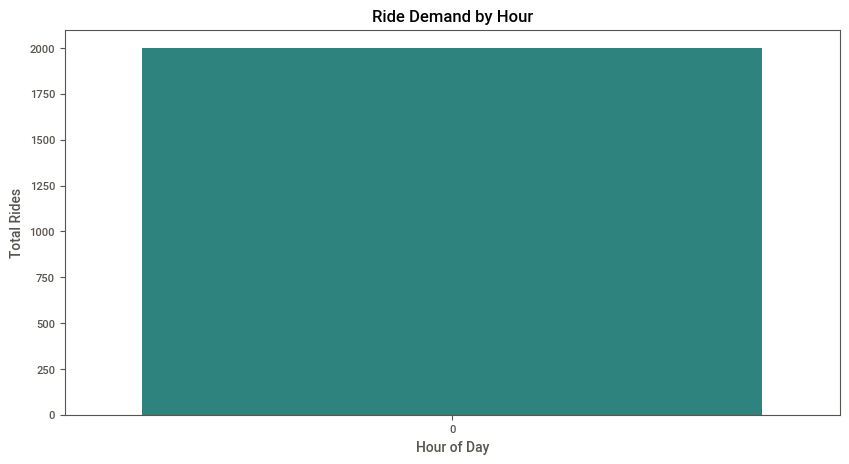

In [77]:
# 8.2.1 Visualize total ride demand for each hour of the day

# Hour column ka sahi naam find karein
hour_col = [col for col in final_df.columns if 'hour' in col.lower()]
col_name = hour_col[0] if hour_col else 'pickup_hour'

# 1. Visualize Ride demand by hour
plt.figure(figsize=(10, 5))
sns.countplot(data=final_df, x=col_name, hue=col_name, legend=False, palette="viridis")
plt.title("Ride Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Rides")
plt.show()

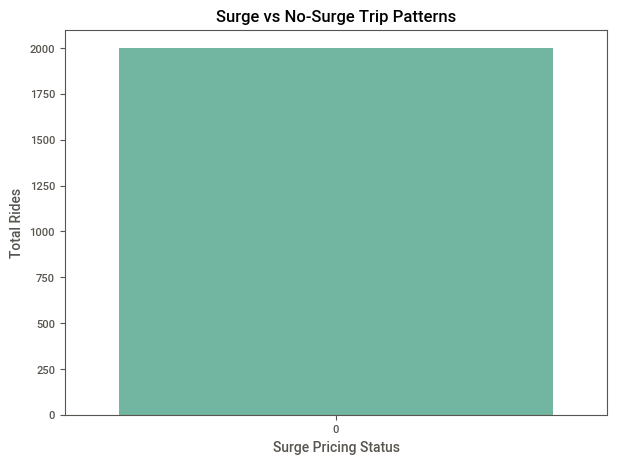

In [78]:
# 8.2.2 Compare total rides between surge and no-surge pricing

# Surge column ka sahi naam find karein
surge_col = [col for col in final_df.columns if 'surge' in col.lower()]
col_name = surge_col[0] if surge_col else 'surge_flag'

# Visualize Surge vs No-Surge trip patterns
plt.figure(figsize=(7, 5))
sns.countplot(data=final_df, x=col_name, hue=col_name, legend=False, palette="Set2")
plt.title("Surge vs No-Surge Trip Patterns")
plt.xlabel("Surge Pricing Status")
plt.ylabel("Total Rides")
plt.show()

### 🟢 8. Bonus: EDA Report & Visualizations

**Main Goal:** Generate an automated data profiling report using Sweetviz and visualize key ride patterns, including hourly demand trends and surge pricing behavior.

## 📋 Project Summary & Checklist

| Step # | Task Name | Status | Key Deliverables / Outputs |
| :--- | :--- | :---: | :--- |
| **Step 1** | Data Ingestion & Setup | ✅ | Loaded `trips_df`, `riders_df`, & `city_zones_df` |
| **Step 2** | Data Cleaning | ✅ | Handled missing values & fixed column data types |
| **Step 3** | Time-based Feature Extraction | ✅ | Extracted `hour`, `dayofweek`, & `is_weekend` |
| **Step 4** | Categorical Encoding | ✅ | Encoded `city_zone` & `ride_type` features |
| **Step 5** | Feature Scaling | ✅ | Normalized continuous variables using `StandardScaler` |
| **Step 6** | Advanced Feature Engineering | ✅ | Created lag features & demand aggregation metrics |
| **Step 7** | Final Dataset Export | ✅ | Merged all features & exported `final_prepared_rides_dataset.csv` |
| **Step 8** | Bonus EDA & Visualizations | ✅ | Generated Sweetviz report + Demand & Surge pattern charts |